Model Methylation score

Import

In [261]:
import pandas as pd

In [ ]:
df=pd.read_csv(r"Results_qPCR.csv")
df.info()
df.head()

In [ ]:
train=df[df["Dataset"]=='Train']
train

In [ ]:
train.reset_index(inplace=True)
train

In [ ]:
y_train = train['Label']
X_train = train[[
                'SEPT9.2',
                'HS3ST2',
                'SEPT9.1'
                ]]
X_train


In [ ]:
test=df[df["Dataset"]=='Test']
test

In [ ]:
test.reset_index(inplace=True)
test

In [ ]:
y_test = test['Label']
X_test = test[[
            'SEPT9.2',
            'HS3ST2',
            'SEPT9.1'
            ]]
X_test

In [ ]:
X_train=X_train.values
X_train

In [215]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import SelectFromModel
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

Search best algorithm

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
models = {
    'LR': LogisticRegression(max_iter=200, random_state=42),
    'RF': RandomForestClassifier(random_state=42),
    'SVM': SVC(max_iter=-1,random_state=42),
    'XGB':XGBClassifier(random_state=42)
}
params = { 
    'LR': { 'C': [1.0], 'class_weight':[None] },
    'RF': { 'n_estimators': [100],'class_weight':[None]},
    'SVM' : {'kernel':['rbf']},
    'XGB': {'n_estimators':[100],'max_depth':[3],'learning_rate':[0.01]}
}

In [ ]:
from HyperclassifierSearch import HyperclassifierSearch
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
search = HyperclassifierSearch(models,params)
best_model = search.train_model(X_train, y_train, cv=cv)

In [ ]:
result = search.evaluate_model()
result

In [ ]:
import matplotlib.pyplot as plt

# Assuming result is a DataFrame from search.evaluate_model()
result = search.evaluate_model()

# Extract algorithm names for labels
result['label'] = result['Estimator'].astype(str)

std = result['std_test_score'].to_list()
mean_ = result['mean_test_score'].to_list()
x = result['label'].to_list()

# Set up the matplotlib figure
plt.figure(figsize=(12,5))

# Create error bar plot
plt.errorbar(x, mean_, yerr=std, fmt='o', ecolor='r', elinewidth=2, capsize=5, capthick=2, markersize=8, markerfacecolor='blue', markeredgewidth=1.5, markeredgecolor='black')

# Annotate each point with its accuracy and standard deviation, positioned slightly above the error bar
for i in range(len(x)):
    plt.annotate(f'{mean_[i]:.2f} ± {std[i]:.2f}',(x[i], mean_[i]), textcoords="offset points", xytext=(10,-5), ha='left', fontsize=20)

# Add title and labels
# plt.ylim(0.6,0.95)
plt.title('SEPT9.2_HS3ST2', fontsize=22,fontweight='bold')
plt.xlabel('Algorithm', fontsize=20,fontweight='bold')
plt.ylabel('Mean accuracy', fontsize=20,fontweight='bold')

# Adjust tick parameters
plt.tick_params(axis='both', which='major', labelsize=20)

# Tight layout for better spacing
plt.tight_layout()

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Show plot
plt.show()

In [29]:
def compute_specificity(y_true, y_pred):
    true_negatives = sum((y_true == 0) & (y_pred == 0))
    actual_negatives = sum(y_true == 0)
    specificity = true_negatives / actual_negatives if actual_negatives != 0 else 0
    return specificity

In [30]:
def compute_sensitivity(y_true, y_pred):
    true_positives = sum((y_true == 1) & (y_pred == 1))
    actual_positives = sum(y_true == 1)
    sensitivity = true_positives / actual_positives if actual_positives != 0 else 0
    return sensitivity

In [31]:
# Define a custom scoring function
def custom_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)
    score = round(((specificity + sensitivity)/2 +specificity)/2, 2)
    return score

# Make the custom scoring function
from sklearn.metrics import make_scorer
custom_scorer = make_scorer(custom_score, greater_is_better=True)

In [32]:
from sklearn.utils import resample
from scipy.stats import norm
def compute_metrics_with_ci(y_true, y_pred, num_bootstraps=1000, confidence_level=0.95):
    specificity_scores = []
    sensitivity_scores = []

    # Bootstrap resampling
    for _ in range(num_bootstraps):
        boot_true, boot_pred = resample(y_true, y_pred)
        specificity = compute_specificity(boot_true, boot_pred)
        sensitivity = compute_sensitivity(boot_true, boot_pred)
        specificity_scores.append(specificity)
        sensitivity_scores.append(sensitivity)

    # Compute mean and confidence interval
    specificity_mean = np.mean(specificity_scores)
    sensitivity_mean = np.mean(sensitivity_scores)
    specificity_ci = norm.interval(confidence_level, loc=specificity_mean, scale=np.std(specificity_scores))
    sensitivity_ci = norm.interval(confidence_level, loc=sensitivity_mean, scale=np.std(sensitivity_scores))

    return {
        'specificity_mean': specificity_mean,
        'specificity_ci': specificity_ci,
        'sensitivity_mean': sensitivity_mean,
        'sensitivity_ci': sensitivity_ci
    }


In [33]:
def create_ml_model(model_type, **kwargs):
    '''
    Create Machine Learning model
    '''
    models = {
        'svm': SVC,
        'random_forest': RandomForestClassifier,
        'logistic_regression': LogisticRegression,
        'xgb': XGBClassifier,
        'lightgbm':lgb,
        'lda': LinearDiscriminantAnalysis
    }
    
    # Retrieve the model class based on the model_type argument
    model = models.get(model_type.lower())
    
    # Check if the model type exists
    if model:
        return model(**kwargs)
    else:
        supported_models = ", ".join(models.keys())
        print(f"Error: Model type '{model_type}' is not supported.\n"
              f"Supported models are: {supported_models}.\n"
              f"Please add your perferred model to create_model function.")
        return None

In [34]:
def kfold_evaluation(model, X, y, kfold):
    '''
    1. Train ML model on KFold
    
    2. Return metrics for each KFold and all KFolds
    '''
    fold_results = [] # average validation data results on all Kfolds
    fold_result_each_kfold = [] # training and validation results on each Kfold

    for train_index, val_index in skf.split(X, y):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict on both sets
        train_predictions = model.predict(X_train)
        val_predictions = model.predict(X_val)
        
        # Calculate metrics for both sets
        train_metrics = calculate_results(y_train, train_predictions)
        val_metrics = calculate_results(y_val, val_predictions)

        fold_result = {
            'fold': len(fold_results) + 1,
            'train_metrics': train_metrics,
            'validation_metrics': val_metrics
        }

        fold_results.append(val_metrics)
        fold_result_each_kfold.append(fold_result)

    # Compute the average metrics over all folds
    model_results = {
        "accuracy": np.mean([result["accuracy"] for result in fold_results]),
        "precision": np.mean([result["precision"] for result in fold_results]),
        "recall": np.mean([result["recall"] for result in fold_results]),
        "f1": np.mean([result["f1"] for result in fold_results])
    }

    # Retrain the model on the entire dataset
    model.fit(X, y)

    return model, fold_result_each_kfold, model_results

In [35]:
from sklearn.metrics import precision_recall_fscore_support
def calculate_results(y_true, y_pred):
    '''
    Calculate accuracy, precision, recall, f1 score for a model
    '''
    model_accuracy = accuracy_score(y_true, y_pred) * 100  # Scale to 1-100
    model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    
    model_results = {
        "accuracy": model_accuracy,
        "precision": model_precision,
        "recall": model_recall,
        "f1": model_f1
    }
    
    return model_results

In [36]:
def format_metrics_compact(metrics):
    '''
    Helper function to format metrics compactly
    '''
    return ", ".join([f"{key.capitalize()}: {value:.2f}" for key, value in metrics.items()])

def display_all_folds_results(model_name, model_results):
    '''
    Print average metrics of validation data on all KFolds
    '''
    print(f"Average {model_name} Performance Metrics Across All Folds (on validation data):")
    print(f"- Accuracy: {model_results['accuracy']:.2f}%")
    print(f"- Precision: {model_results['precision']:.4f}")
    print(f"- Recall: {model_results['recall']:.4f}")
    print(f"- F1 Score: {model_results['f1']:.4f}")

In [37]:
def compare_baseline_to_new_results(baseline_results, new_model_results, baseline_name='Baseline', new_model_name='New Model'):
    '''
    Compare baseline and new model results on metrics and plot the results using a line graph.
    '''
    metrics = list(baseline_results.keys())
    baseline_scores = [baseline_results[metric] * 100 if metric != 'accuracy' else baseline_results[metric] for metric in metrics]
    new_model_scores = [new_model_results[metric] * 100 if metric != 'accuracy' else new_model_results[metric] for metric in metrics]

    # Textual comparison
    # for key, value in baseline_results.items():
        # print(f"{baseline_name} {key}: {value:.2f}, {new_model_name} {key}: {new_model_results[key]:.2f}, Difference: {new_model_results[key]-value:.2f}")

    # Set up the seaborn style and palette
    sns.set(style="whitegrid", palette="muted")
    colors = ["#3498db", "#e74c3c"]  # Blue for baseline, Red for new model

    # Plotting
    x = np.arange(len(metrics))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, baseline_scores, label=baseline_name, marker='o', markersize=6, linewidth=2, color=colors[0])
    ax.plot(x, new_model_scores, label=new_model_name, marker='s', markersize=6, linewidth=2, color=colors[1])
    
    # Adjust y-axis range
    max_score = max(max(baseline_scores), max(new_model_scores))
    min_score = min(min(baseline_scores), min(new_model_scores))
    ax.set_ylim([min_score - 1, max_score + 1])  # Add padding to the top and bottom
    ax.set_facecolor('#f8f9fa')  # Light gray background

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Scores (%)')
    ax.set_title(f'Performance Comparison: {baseline_name} vs {new_model_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()

    # Attach a text label at each marker, displaying its height with increased vertical offset
    label_offset = 0.25  # Increased vertical offset for the labels
    for i in range(len(metrics)):
        ax.text(x[i], baseline_scores[i] + label_offset, f'{baseline_scores[i]:.2f}%', ha='center', va='bottom')
        ax.text(x[i], new_model_scores[i] + label_offset, f'{new_model_scores[i]:.2f}%', ha='center', va='bottom')

    fig.tight_layout()
    plt.show()

In [38]:
def display_each_fold_result(model_name, fold_results):
    '''
    Print metrics of training and validation data on each KFold and plot the accuracy graph using Seaborn.
    '''
    # Set up the seaborn style and palette
    sns.set(style="whitegrid", palette="muted")
    # colors = ["#3498db", "#e74c3c"]  
    colors = ["r", "b"]

    # Header
    print(f"{model_name} Performance Metrics Across Each Fold (on training and validation data):")
    print()
    print(f"{'Fold':<5} | {'Training Metrics':<70} | {'Validation Metrics':<70}")
    print("-" * 150)

    # Prepare data for plotting
    train_accuracies = []
    val_accuracies = []
    folds = []

    # Display results for each fold and collect data for graph
    for result in fold_results:
        train_metrics_formatted = format_metrics_compact(result['train_metrics'])
        val_metrics_formatted = format_metrics_compact(result['validation_metrics'])
        print(f"{result['fold']:<5} | {train_metrics_formatted:<70} | {val_metrics_formatted:<70}")

        # Append data for graph
        folds.append(result['fold'])
        train_accuracies.append(result['train_metrics']['accuracy'])
        val_accuracies.append(result['validation_metrics']['accuracy'])

    # Plotting the accuracies using Seaborn
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(x=folds, y=train_accuracies, label='Training Accuracy', marker='o', color=colors[0])
    sns.lineplot(x=folds, y=val_accuracies, label='Validation Accuracy', marker='o', color=colors[1])
    ax.set_facecolor('#f8f9fa')  # Light gray background

    # Adding percentages on markers
    label_offset = 0.25  # Increased vertical offset for the labels
    for i, (tr_acc, val_acc) in enumerate(zip(train_accuracies, val_accuracies)):
        ax.text(folds[i], tr_acc + label_offset, f"{tr_acc:.2f}%", ha='center', va='bottom')
        ax.text(folds[i], val_acc + label_offset, f"{val_acc:.2f}%", ha='center', va='bottom')

    plt.title(f"{model_name} model: Training vs Validation Accuracy per Fold")
    plt.xlabel('Fold')
    plt.ylabel('Accuracy (%)')
    plt.xticks(folds)
    plt.legend()
    ax.margins(y=1)  # Add 10% padding to the top and bottom
    fig.tight_layout()
    plt.show()

Tunning hyperparameter

LR

In [ ]:
# Grid searching key hyperparametres for ridge classifier
from sklearn.datasets import make_blobs
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import RidgeClassifier
# define models and parameters
model = LogisticRegression(class_weight ='balanced',random_state=42)
solvers = ['newton-cg', 'lbfgs', 'liblinear']
penalty = ['l2','l1','none']
c_values = np.power(10., np.arange(-4, 4))
# #define scoring
# y_predictions = model.predict(X_train)
# ranking_metric=ranking_metric(y_train, y_predictions)
# from sklearn.metrics import make_scorer
# scoring= make_scorer(ranking_metric, greater_is_better = True)
# define grid search
grid = dict(solver=solvers,penalty=penalty,C=c_values)
cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='roc_auc' ,error_score=0)
grid_result = grid_search.fit(X_train, y_train)
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

XGB

In [ ]:
# example of grid searching key hyperparameters for RandomForestClassifier
from sklearn.datasets import make_blobs
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV

model = XGBClassifier(objective='binary:logistic',random_state=42) 
n_estimators = [100, 1000]
max_depth = [3, 4, 5]
learning_rate=[0.1, 0.01, 0.001]
# #define scoring
# y_predictions = model.predict(X_train)
# ranking_metric=ranking_metric(y_train, y_predictions)
# from sklearn.metrics import make_scorer
# scoring= make_scorer(ranking_metric, greater_is_better = True)
# define grid search
grid = dict(n_estimators=n_estimators,max_depth=max_depth,learning_rate=learning_rate)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='roc_auc',error_score=0)
grid_result = grid_search.fit(X_train, y_train)
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

SVM

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import RidgeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Define models and parameters
model = SVC(random_state=1, probability=True)
kernel = ['linear', 'poly', 'rbf', 'sigmoid']
c_values = [100, 10, 1.0, 0.1, 0.01]
class_weight = ['balanced', None]
gamma = ['scale', 'auto']
tol = [0.00001, 0.0001, 0.001, 0.01, 0.1]

# Define grid search
grid = dict(kernel=kernel, class_weight=class_weight, C=c_values, gamma=gamma, tol=tol)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='roc_auc', error_score=0, refit=True, verbose=3)
grid_result = grid_search.fit(X_train, y_train)

# Summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

RF

In [ ]:
# example of grid searching key hyperparameters for RandomForestClassifier
from sklearn.datasets import make_blobs
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
criterion = ['gini', 'entropy']
n_estimators = [50,200, 300,400,500]
class_weight = ['balanced',None]
max_features = [1, 10, 20, 30, 50]
min_samples_leaf=[10,20,50]
min_samples_split=[10,20,50]
#define scoring
# y_predictions = model.predict(X_train)
# ranking_metric=ranking_metric(y_train, y_predictions)
# from sklearn.metrics import make_scorer
# scoring= make_scorer(ranking_metric, greater_is_better = True)
# define grid search
grid = dict(criterion=criterion, n_estimators=n_estimators,max_features=max_features,class_weight =class_weight,min_samples_leaf=min_samples_leaf,min_samples_split=min_samples_split)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='roc_auc',error_score=0)
grid_result = grid_search.fit(X_train, y_train)
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Result

In [ ]:
X_train=X_train.values
X_train

In [42]:
skf=cv

In [70]:
lr_model = create_ml_model('logistic_regression',C=0.1, penalty='l2',solver='lbfgs',class_weight ='balanced',random_state=42)
# lr_model = create_ml_model('logistic_regression',C=1, max_iter=200 ,class_weight =None,random_state=1)

In [ ]:
lr_model, lr_each_fold_results, lr_results = kfold_evaluation(lr_model, X_train, y_train, skf)

In [ ]:
display_all_folds_results("Logistic Regression", lr_results)

In [ ]:
display_each_fold_result("Logistic Regression",lr_each_fold_results)

In [131]:
from sklearn.model_selection import StratifiedKFold

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

In [98]:
xgb_model= create_ml_model('xgb',
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        # subsample=0.8,
        # colsample_bytree=0.8,
        # eval_metric="logloss",
        random_state=42
    )

In [99]:
xgb_model, xgb_each_fold_results, xgb_results = kfold_evaluation(xgb_model, X_train, y_train, skf)

In [ ]:
display_all_folds_results("XGB", xgb_results)

In [ ]:
display_each_fold_result("XGB",xgb_each_fold_results)

In [ ]:
svm_model= create_ml_model('svm', random_state=42, C=0.1, kernel='rbf',probability=True, gamma='auto',tol=0.00001, class_weight=None,)

In [ ]:
svm_model, svm_each_fold_results, svm_results = kfold_evaluation(svm_model, X_train, y_train, skf)

In [ ]:
display_all_folds_results("SVM", svm_results)

In [ ]:
display_each_fold_result("SVM",svm_each_fold_results)

In [606]:
rf_model= create_ml_model('random_forest', criterion='entropy', max_features=1, min_samples_leaf=30,min_samples_split=50, n_estimators=500, class_weight = None, random_state=1)
# rf_model= create_ml_model('random_forest', n_estimators= 200, random_state=1)

In [607]:
rf_model, rf_each_fold_results, rf_results = kfold_evaluation(rf_model, X_train, y_train, skf)

In [ ]:
display_all_folds_results("Random Forest", rf_results)

In [ ]:
display_each_fold_result("Random Forest",rf_each_fold_results)

Fit model

In [610]:
model=rf_model

In [ ]:
proba_train1 = cross_val_predict(model, X_train, y_train, cv=skf, method='predict_proba')
[print(x) for x in proba_train1[:,1]]

In [ ]:
dframe_train=pd.DataFrame({'SampleID':train['SampleID'],'Class':train['Class'],'Label':train['Label'],'Probability':proba_train1[:,1]})

In [ ]:
y_pred = model.predict_proba(X_test)
print(y_pred)

In [ ]:
proba_test=pd.DataFrame({'SampleID':test['SampleID'],'Class':test['Class'],'Label':test['Label'],'Probability':y_pred[:,1]})

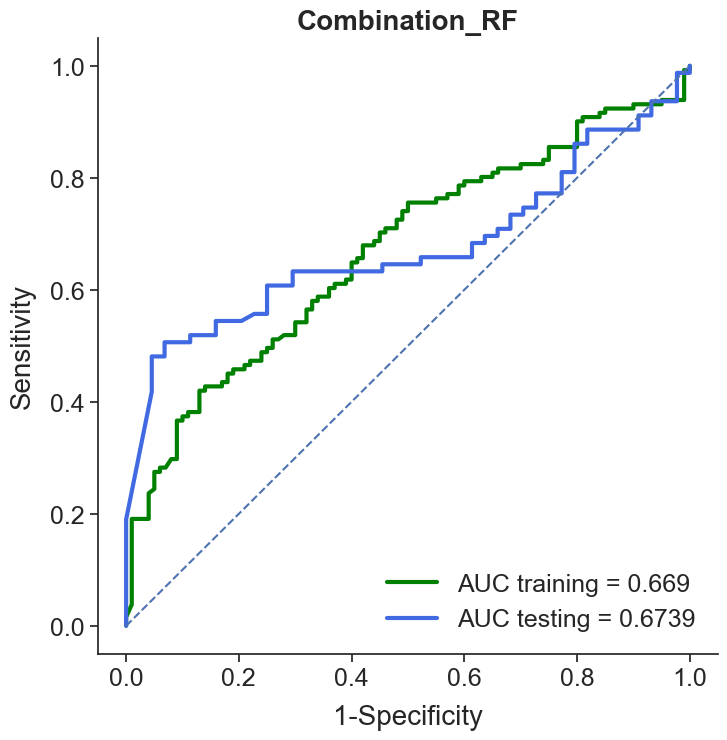

In [615]:
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (8,8))
sns.set_theme(context='notebook', style='ticks', palette='deep', font='sans-serif', font_scale=1.4, color_codes=True, rc=None)

# #CNN
fpr_TRAIN, tpr_TRAIN, thresholds_TRAIN = metrics.roc_curve(y_train,  proba_train1[:, 1])
auc_TRAIN = metrics.roc_auc_score(y_train,  proba_train1[:, 1])
plt.plot(fpr_TRAIN,tpr_TRAIN,label="AUC training = "+str(round(auc_TRAIN, 4)), linewidth = 3, color='green')


fpr_TEST, tpr_TEST, thresholds_TEST = metrics.roc_curve(y_test,  y_pred[:, 1])
auc_TEST = metrics.roc_auc_score(y_test,  y_pred[:, 1])
plt.plot(fpr_TEST,tpr_TEST,label="AUC testing = "+str(round(auc_TEST, 4)), linewidth = 3, color='royalblue')

# fpr_VAL, tpr_VAL, thresholds_VAL = metrics.roc_curve(y_val,  y_pred1[:, 1])
# auc_VAL = metrics.roc_auc_score(y_val,  y_pred1[:, 1])
# plt.plot(fpr_VAL,tpr_VAL,label="AUC train_NonBS = "+str(round(auc_VAL, 4)), linewidth = 3, color='coral')

# fpr_UN, tpr_UN, thresholds_UN = metrics.roc_curve(y_unseen,  y_pred2[:, 1])
# auc_UN = metrics.roc_auc_score(y_unseen,  y_pred2[:, 1])
# plt.plot(fpr_UN,tpr_UN,label="AUC test_NonBS = "+str(round(auc_UN, 4)), linewidth = 3, color='purple')

plt.plot([0, 1], ls="--")
plt.title('Combination_RF', fontsize=20, fontweight='bold')
plt.ylabel('Sensitivity', labelpad=10, fontsize=20)
plt.xlabel('1-Specificity', labelpad=10, fontsize=20)
legend=plt.legend(loc=4, fontsize=18)
#plt.plot([0.05,0.05],[1,0],color = 'k', label = 'Fold Change = 2',linestyle = ':', linewidth=1)

legend.get_frame().set_linewidth(0) 

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tick_params(axis='both', which='major', labelsize=18)

# Show the plot
plt.show()

In [ ]:
import joblib

# model đã train
# X_train là DataFrame dùng để train

model_info = {
    "model": model,
    "feature_order": X_train.columns.tolist()
}

joblib.dump(model_info, "All targets.pkl")

print("Model saved successfully!")

Model saved successfully!


AUC

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"Results_qPCR_Methylation model.csv")
df.info()
df

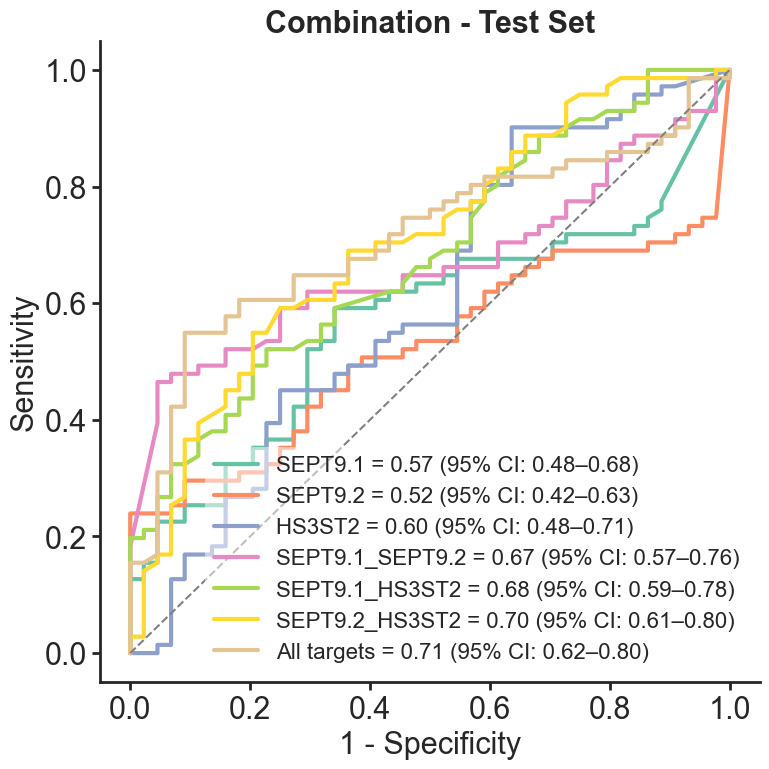

In [630]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. SELECT TEST DATA
# =========================
df_test = df[df["Dataset"] == "Test"].copy()

# =========================
# 2. MODELS
# =========================
models = [
    "SEPT9.1",
    "SEPT9.2",
    "HS3ST2",
    "SEPT9.1_SEPT9.2",
    "SEPT9.1_HS3ST2",
    "SEPT9.2_HS3ST2",
    "All targets"
]

# =========================
# 3. ROC CURVES
# =========================
plt.figure(figsize=(8, 8))

y_true = df_test["Label"]

palette = sns.color_palette("Set2", len(models))

n_bootstrap = 1000
rng = np.random.default_rng(42)

for i, model in enumerate(models):

    y_score = df_test[model]

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    # Bootstrap CI
    auc_boot = []

    for _ in range(n_bootstrap):

        idx = rng.choice(len(df_test), len(df_test), replace=True)

        y_boot = y_true.iloc[idx]
        score_boot = y_score.iloc[idx]

        if len(np.unique(y_boot)) < 2:
            continue

        auc_boot.append(
            roc_auc_score(y_boot, score_boot)
        )

    ci_lower = np.percentile(auc_boot, 2.5)
    ci_upper = np.percentile(auc_boot, 97.5)

    # Plot ROC
    plt.plot(
        fpr,
        tpr,
        color=palette[i],
        linewidth=3,
        label=f"{model} = {auc:.2f} (95% CI: {ci_lower:.2f}–{ci_upper:.2f})"
    )

# =========================
# Random classifier
# =========================
plt.plot(
    [0, 1],
    [0, 1],
    '--',
    color='gray',
    linewidth=1.5
)

# =========================
# Formatting
# =========================
# plt.xlim(0, 1)
# plt.ylim(0, 1.02)

plt.xlabel("1 - Specificity", fontsize=22)
plt.ylabel("Sensitivity", fontsize=22)
plt.title("Combination - Test Set", fontsize=22, fontweight="bold")
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

ax = plt.gca()
ax.tick_params(axis='both', width=2, length=6)

ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend = plt.legend(
    loc="lower right",
    fontsize=16,
    frameon=True
)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_alpha(0.5)
legend.get_frame().set_edgecolor("none")

plt.tight_layout()
plt.show()

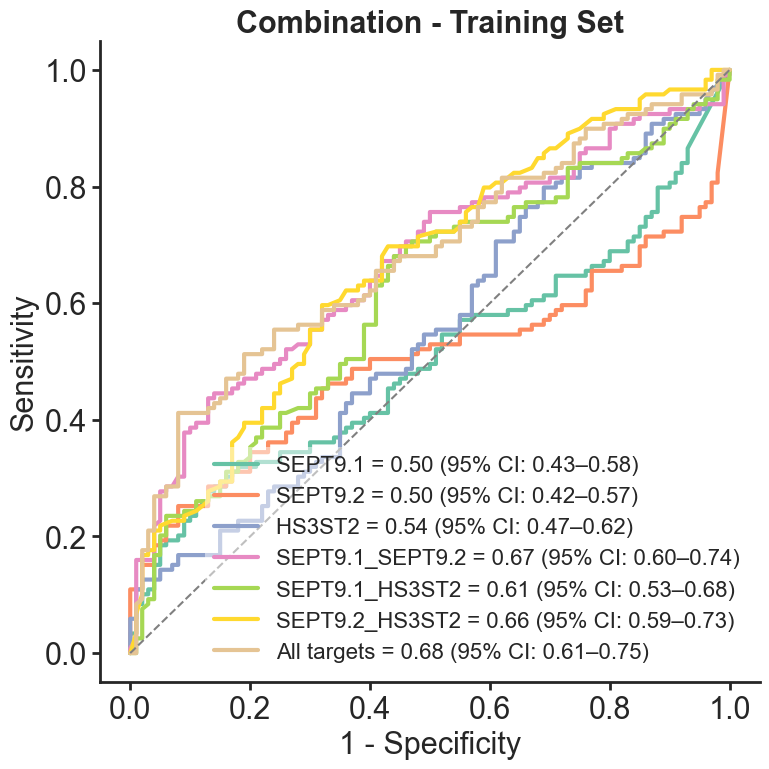

In [629]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. SELECT TEST DATA
# =========================
df_test = df[df["Dataset"] == "Train"].copy()

# =========================
# 2. MODELS
# =========================
models = [
    "SEPT9.1",
    "SEPT9.2",
    "HS3ST2",
    "SEPT9.1_SEPT9.2",
    "SEPT9.1_HS3ST2",
    "SEPT9.2_HS3ST2",
    "All targets"
]

# =========================
# 3. ROC CURVES
# =========================
plt.figure(figsize=(8, 8))

y_true = df_test["Label"]

palette = sns.color_palette("Set2", len(models))

n_bootstrap = 1000
rng = np.random.default_rng(42)

for i, model in enumerate(models):

    y_score = df_test[model]

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    # Bootstrap CI
    auc_boot = []

    for _ in range(n_bootstrap):

        idx = rng.choice(len(df_test), len(df_test), replace=True)

        y_boot = y_true.iloc[idx]
        score_boot = y_score.iloc[idx]

        if len(np.unique(y_boot)) < 2:
            continue

        auc_boot.append(
            roc_auc_score(y_boot, score_boot)
        )

    ci_lower = np.percentile(auc_boot, 2.5)
    ci_upper = np.percentile(auc_boot, 97.5)

    # Plot ROC
    plt.plot(
        fpr,
        tpr,
        color=palette[i],
        linewidth=3,
        label=f"{model} = {auc:.2f} (95% CI: {ci_lower:.2f}–{ci_upper:.2f})"
    )

# =========================
# Random classifier
# =========================
plt.plot(
    [0, 1],
    [0, 1],
    '--',
    color='gray',
    linewidth=1.5
)

# =========================
# Formatting
# =========================
# plt.xlim(0, 1)
# plt.ylim(0, 1.02)

plt.xlabel("1 - Specificity", fontsize=22)
plt.ylabel("Sensitivity", fontsize=22)
plt.title("Combination - Training Set", fontsize=22, fontweight="bold")
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

ax = plt.gca()
ax.tick_params(axis='both', width=2, length=6)

ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend = plt.legend(
    loc="lower right",
    fontsize=16,
    frameon=True
)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_alpha(0.5)
legend.get_frame().set_edgecolor("none")

plt.tight_layout()
plt.show()

Cutoff_Methylation model

In [ ]:
df=pd.read_csv(r"Results_qPCR.csv")
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SampleID               334 non-null    object 
 1   Dataset_build          334 non-null    object 
 2   Dataset                334 non-null    object 
 3   Dataset all            334 non-null    object 
 4   Panel                  334 non-null    object 
 5   ACTB                   334 non-null    float64
 6   Class                  334 non-null    object 
 7   Label                  334 non-null    int64  
 8   Run                    334 non-null    object 
 9   Gender                 334 non-null    object 
 10  Age                    334 non-null    int64  
 11  Stage                  136 non-null    object 
 12  Fragmentomic score     334 non-null    float64
 13  Methylation score      334 non-null    float64
 14  SEPT9.1                334 non-null    float64
 15  SEPT9.

,SampleID,Dataset_build,Dataset,Dataset all,Panel,ACTB,Class,Label,Run,Gender,...,SEPT9.1_SEPT9.2,SEPT9.1_HS3ST2,SEPT9.2_HS3ST2,LR_FS_SEPT9.1,LR_FS_SEPT9.2,LR_FS_HS3ST2,LR_FS_SEPT9.1_SEPT9.2,LR_FS_SEPT9.1_HS3ST2,LR_FS_SEPT9.2_HS3ST2,LR_FS_Alltargets
0,LABI63,Train,Train,Combination dataset,MS3,32.715491,CRC,1,R7128,Male,...,0.752778,0.950394,1.000,0.931833,0.963418,0.685256,0.939337,0.936944,0.947809,0.949206
1,0ACDCA93A11,Train,Train,Combination dataset,MS4,33.852386,PreC,1,R9267,Male,...,0.733498,0.528529,0.490,0.673092,0.670387,0.672843,0.725996,0.668296,0.652236,0.691051
2,K2AAEQ24,Test,Test,Combination dataset,MS4,33.875065,Healthy,0,R8465,Male,...,0.457898,0.300365,0.190,0.273638,0.273222,0.275829,0.249731,0.249312,0.205481,0.244737
3,K2AAEQ20,Train,Train,Combination dataset,MS4,32.092414,Healthy,0,R8465,Female,...,0.456530,0.547244,0.855,0.242533,0.243548,0.249348,0.220365,0.246058,0.313963,0.224094
4,K2AAEQ14,Train,Train,Combination dataset,MS4,33.460771,Healthy,0,R8465,Female,...,0.536964,0.319467,0.360,0.376230,0.373751,0.381674,0.375866,0.350685,0.327981,0.346784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,0ACDCM02A11,Test,Test,Combination dataset,MS4,31.212470,CRC,1,R10563,Male,...,0.782050,0.564923,0.775,0.933094,0.936829,0.927640,0.945294,0.926047,0.938272,0.948818
330,0ACDCC30A11,Test,Test,Combination dataset,MS4,31.134889,CRC,1,R9749,Male,...,0.782050,0.948313,0.890,0.928646,0.927609,0.928793,0.945294,0.940225,0.945297,0.947598
331,0ACDCE58A11,Test,Test,Combination dataset,MS4,31.289011,CRC,1,R9917,Male,...,0.711357,0.656403,0.705,0.924397,0.921223,0.929268,0.939478,0.929688,0.933592,0.944505
332,0ACDCF30A11,Test,Test,Combination dataset,MS4,31.216668,CRC,1,R10044,Female,...,0.782050,0.959685,0.900,0.856967,0.862740,0.855123,0.888538,0.879259,0.890448,0.896666


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix

# =========================
# Binary label
# =========================
df['Label'] = df['Class'].map({
    'CRC': 1,
    'PreC': 1,
    'Healthy': 0
})

# =========================
# Features
# =========================
features =  df.columns[12:]

# =========================
# Split train/test
# =========================
train = df[df['Dataset'] == 'Train'].copy()
test = df[df['Dataset'] == 'Test'].copy()

results = []
pred_train = pd.DataFrame(index=train.index)
pred_test = pd.DataFrame(index=test.index)

for col in features:

    # -------------------------
    # Find cutoff on TRAIN only
    # -------------------------
    y_train = train['Label']
    scores_train = train[col].fillna(0)

    fpr, tpr, thresholds = roc_curve(y_train, scores_train)

    specificity = 1 - fpr

    valid = np.where(specificity >= 0.95)[0]

    if len(valid) == 0:
        best_idx = len(thresholds) - 1
    else:
        best_idx = valid[np.argmax(tpr[valid])]

    cutoff = thresholds[best_idx]

    # -------------------------
    # Apply cutoff to TRAIN
    # -------------------------
    train_pred = (scores_train >= cutoff).astype(int)
    pred_train[f'{col}_pred'] = train_pred

    tn, fp, fn, tp = confusion_matrix(y_train, train_pred).ravel()

    results.append({
        'Dataset': 'Train',
        'Feature': col,
        'Cutoff': cutoff,
        'Sensitivity': tp/(tp+fn),
        'Specificity': tn/(tn+fp),
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn
    })

    # -------------------------
    # Apply SAME cutoff to TEST
    # -------------------------
    y_test = test['Label']
    scores_test = test[col].fillna(0)

    test_pred = (scores_test >= cutoff).astype(int)
    pred_test[f'{col}_pred'] = test_pred

    tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

    results.append({
        'Dataset': 'Test',
        'Feature': col,
        'Cutoff': cutoff,
        'Sensitivity': tp/(tp+fn),
        'Specificity': tn/(tn+fp),
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn
    })

# =========================
# Summary
# =========================
results_df = pd.DataFrame(results)

print(results_df)

# =========================
# Prediction tables
# =========================
train_prediction = pd.concat(
    [
        train[['SampleID', 'Class', 'Label', 'Dataset']],
        pred_train
    ],
    axis=1
)

test_prediction = pd.concat(
    [
        test[['SampleID', 'Class', 'Label', 'Dataset']],
        pred_test
    ],
    axis=1
)

df = pd.concat(
    [train_prediction, test_prediction],
    axis=0
).sort_index()

print(train_prediction.head())
print(test_prediction.head())

   Dataset                Feature    Cutoff  Sensitivity  Specificity  TP  FP  \
0    Train     Fragmentomic score  0.420000     0.747899     0.910000  89   9   
1     Test     Fragmentomic score  0.420000     0.718310     0.886364  51   5   
2    Train      Methylation score  0.632046     0.436975     0.900000  52  10   
3     Test      Methylation score  0.632046     0.450704     0.931818  32   3   
4    Train                SEPT9.1  0.071631     0.235294     0.900000  28  10   
5     Test                SEPT9.1  0.071631     0.253521     0.886364  18   5   
6    Train                SEPT9.2  0.089372     0.252101     0.920000  30   8   
7     Test                SEPT9.2  0.089372     0.239437     1.000000  17   0   
8    Train                 HS3ST2  0.586864     0.168067     0.920000  20   8   
9     Test                 HS3ST2  0.586864     0.098592     0.931818   7   3   
10   Train            All targets  0.676877     0.411765     0.920000  49   8   
11    Test            All ta

In [7]:
results_df

,Dataset,Feature,Cutoff,Sensitivity,Specificity,TP,FP,FN,TN
0,Train,Fragmentomic score,0.420000,0.747899,0.910000,89,9,30,91
1,Test,Fragmentomic score,0.420000,0.718310,0.886364,51,5,20,39
2,Train,Methylation score,0.632046,0.436975,0.900000,52,10,67,90
3,Test,Methylation score,0.632046,0.450704,0.931818,32,3,39,41
4,Train,SEPT9.1,0.071631,0.235294,0.900000,28,10,91,90
5,Test,SEPT9.1,0.071631,0.253521,0.886364,18,5,53,39
6,Train,SEPT9.2,0.089372,0.252101,0.920000,30,8,89,92
7,Test,SEPT9.2,0.089372,0.239437,1.000000,17,0,54,44
8,Train,HS3ST2,0.586864,0.168067,0.920000,20,8,99,92
9,Test,HS3ST2,0.586864,0.098592,0.931818,7,3,64,41


In [9]:
df

,SampleID,Class,Label,Dataset,Fragmentomic score_pred,Methylation score_pred,SEPT9.1_pred,SEPT9.2_pred,HS3ST2_pred,All targets_pred,SEPT9.1_SEPT9.2_pred,SEPT9.1_HS3ST2_pred,SEPT9.2_HS3ST2_pred,LR_FS_SEPT9.1_pred,LR_FS_SEPT9.2_pred,LR_FS_HS3ST2_pred,LR_FS_SEPT9.1_SEPT9.2_pred,LR_FS_SEPT9.1_HS3ST2_pred,LR_FS_SEPT9.2_HS3ST2_pred,LR_FS_Alltargets_pred
0,LABI63,CRC,1,Train,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,0ACDCA93A11,PreC,1,Train,1,0,1,0,0,0,1,0,0,1,1,1,1,1,1,1
2,K2AAEQ24,Healthy,0,Test,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,K2AAEQ20,Healthy,0,Train,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,K2AAEQ14,Healthy,0,Train,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,0ACDCM02A11,CRC,1,Test,1,1,1,1,0,1,1,0,0,1,1,1,1,1,1,1
330,0ACDCC30A11,CRC,1,Test,1,1,1,1,0,1,1,1,0,1,1,1,1,1,1,1
331,0ACDCE58A11,CRC,1,Test,1,1,0,0,0,1,1,0,0,1,1,1,1,1,1,1
332,0ACDCF30A11,CRC,1,Test,1,1,1,1,0,1,1,1,0,1,1,1,1,1,1,1


In [ ]:
results_df.to_csv(r"Result_qPCR_Cutoff_Spec95_LR_Full.csv",index=False)

In [ ]:
df.to_csv(r"Result_qPCR_Prediction_Spec95_LR_Full.csv",index=False)

Selected Methylation model

In [1]:
import pandas as pd

In [ ]:
df=pd.read_csv(r"Result_qPCR_Prediction_Spec95_LR_Full.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   SampleID               334 non-null    object
 1   Class                  334 non-null    object
 2   Label                  334 non-null    int64 
 3   Dataset                334 non-null    object
 4   FS                     334 non-null    int64 
 5   SEPT9.1                334 non-null    int64 
 6   SEPT9.2                334 non-null    int64 
 7   HS3ST2                 334 non-null    int64 
 8   SEPT9.1_SEPT9.2        334 non-null    int64 
 9   SEPT9.1_HS3ST2         334 non-null    int64 
 10  SEPT9.2_HS3ST2         334 non-null    int64 
 11  All targets            334 non-null    int64 
 12  LR_FS_SEPT9.1          334 non-null    int64 
 13  LR_FS_SEPT9.2          334 non-null    int64 
 14  LR_FS_HS3ST2           334 non-null    int64 
 15  LR_FS_SEPT9.1_SEPT9.2  

,SampleID,Class,Label,Dataset,FS,SEPT9.1,SEPT9.2,HS3ST2,SEPT9.1_SEPT9.2,SEPT9.1_HS3ST2,...,LR_FS_SEPT9.1_HS3ST2,LR_FS_SEPT9.2_HS3ST2,LR_FS_All targets,FS_OR_SEPT9.1,FS_OR_SEPT9.2,FS_OR_HS3ST2,FS_OR_SEPT9.1_SEPT9.2,FS_OR_SEPT9.1_HS3ST2,FS_OR_SEPT9.2_HS3ST2,FS_OR_All targets
0,LABI63,CRC,1,Combination - Training Set,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1,0ACDCA93A11,PreC,1,Combination - Training Set,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
2,K2AAEQ24,Healthy,0,Combination - Test Set,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,K2AAEQ20,Healthy,0,Combination - Training Set,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,K2AAEQ14,Healthy,0,Combination - Training Set,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Combination - Training Set: 219 samples

Combination - Test Set: 115 samples

================ RESULTS ================
                       Dataset                  Model  Specificity  \
0   Combination - Training Set                     FS        92.00   
1   Combination - Training Set                SEPT9.1        95.00   
2   Combination - Training Set                SEPT9.2        95.00   
3   Combination - Training Set                 HS3ST2        95.00   
4   Combination - Training Set        SEPT9.1_SEPT9.2        95.00   
5   Combination - Training Set         SEPT9.1_HS3ST2        95.00   
6   Combination - Training Set         SEPT9.2_HS3ST2        95.00   
7   Combination - Training Set            All targets        96.00   
8   Combination - Training Set          LR_FS_SEPT9.1        95.00   
9   Combination - Training Set          LR_FS_SEPT9.2        95.00   
10  Combination - Training Set           LR_FS_HS3ST2        95.00   
11  Combination - Training Set  LR_FS_S

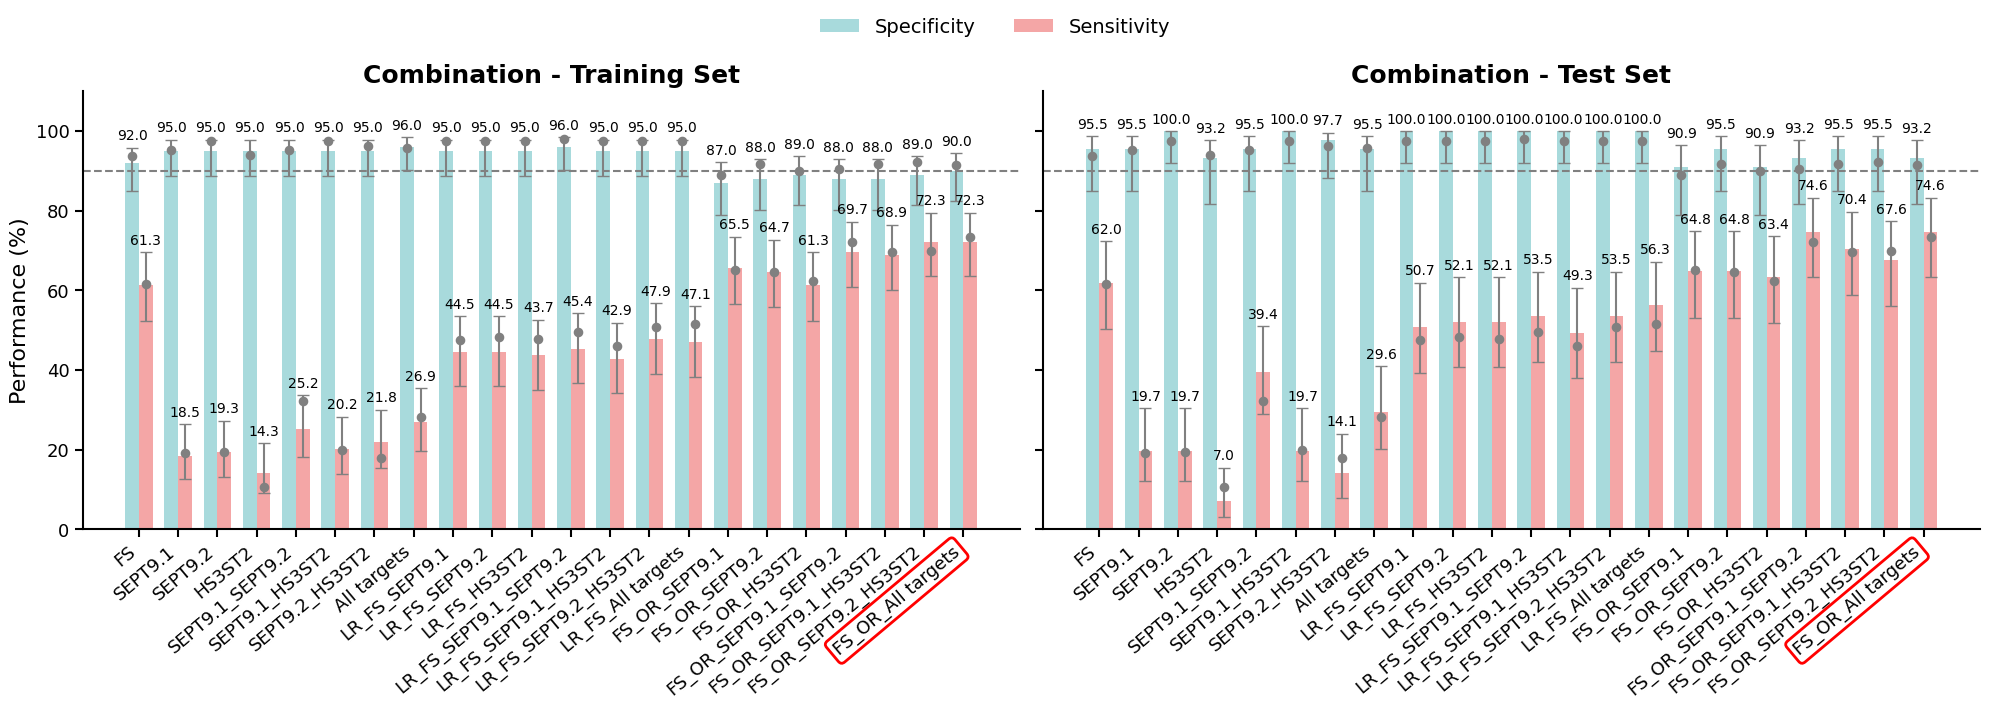

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.metrics import confusion_matrix, recall_score
from statsmodels.stats.proportion import proportion_confint


# ==========================================================
# Prediction columns (binary 0/1)
# ==========================================================

prediction_cols = [
    c for c in df.columns
    if c not in [
        "SampleID",
        "Class",
        "Label",
        "Dataset",
        "Dataset_build"
    ]
]


# ==========================================================
# Calculate performance + 95% Wilson CI
# ==========================================================

results = []

datasets = [
    "Combination - Training Set",
    "Combination - Test Set"
]


for dataset in datasets:

    df_sub = df[df["Dataset"] == dataset].copy()

    print(f"\n{dataset}: {len(df_sub)} samples")

    for model in prediction_cols:

        # Remove missing values for this model
        valid = df_sub[["Label", model]].dropna()

        y_true = valid["Label"].astype(int)
        y_pred = valid[model].astype(int)

        # Skip empty data
        if len(y_true) == 0:
            print(f"WARNING: {model} has no valid samples in {dataset}")
            continue

        # --------------------------------------------------
        # Confusion matrix
        # --------------------------------------------------

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()


        # ==================================================
        # Specificity
        # ==================================================

        n_spec = tn + fp

        if n_spec > 0:

            specificity = tn / n_spec

            spec_low, spec_high = proportion_confint(
                count=tn,
                nobs=n_spec,
                alpha=0.05,
                method="wilson"
            )

        else:

            specificity = np.nan
            spec_low = np.nan
            spec_high = np.nan


        # ==================================================
        # Sensitivity
        # ==================================================

        n_sens = tp + fn

        if n_sens > 0:

            sensitivity = tp / n_sens

            sens_low, sens_high = proportion_confint(
                count=tp,
                nobs=n_sens,
                alpha=0.05,
                method="wilson"
            )

        else:

            sensitivity = np.nan
            sens_low = np.nan
            sens_high = np.nan


        # ==================================================
        # Save results
        # ==================================================

        results.append({
            "Dataset": dataset,
            "Model": model,

            "Specificity": specificity * 100,
            "Spec_low": spec_low * 100,
            "Spec_high": spec_high * 100,

            "Sensitivity": sensitivity * 100,
            "Sens_low": sens_low * 100,
            "Sens_high": sens_high * 100,

            "N": len(y_true)
        })


# ==========================================================
# Results dataframe
# ==========================================================

results_df = pd.DataFrame(results)


print("\n================ RESULTS ================")

print(
    results_df[
        [
            "Dataset",
            "Model",
            "Specificity",
            "Sensitivity",
            "N"
        ]
    ].round(2)
)


# ==========================================================
# Check CI consistency
# ==========================================================

print("\nPotential problematic Specificity CIs:")

check_spec = results_df[
    (results_df["Spec_low"] > results_df["Specificity"]) |
    (results_df["Spec_high"] < results_df["Specificity"])
]

print(
    check_spec[
        [
            "Dataset",
            "Model",
            "Specificity",
            "Spec_low",
            "Spec_high"
        ]
    ]
)


print("\nPotential problematic Sensitivity CIs:")

check_sens = results_df[
    (results_df["Sens_low"] > results_df["Sensitivity"]) |
    (results_df["Sens_high"] < results_df["Sensitivity"])
]

print(
    check_sens[
        [
            "Dataset",
            "Model",
            "Sensitivity",
            "Sens_low",
            "Sens_high"
        ]
    ]
)


# ==========================================================
# SELECT BEST MODEL FROM TRAINING SET ONLY
#
# Criteria:
# 1. Specificity >= 90%
# 2. Highest Sensitivity among eligible models
# ==========================================================

train_results = results_df[
    results_df["Dataset"] == "Combination - Training Set"
].copy()


eligible_train = train_results[
    train_results["Specificity"] >= 90
].copy()


if len(eligible_train) > 0:

    best_row = eligible_train.loc[
        eligible_train["Sensitivity"].idxmax()
    ]

    best_model = best_row["Model"]

else:

    best_model = None


print("\n==========================================")
print("MODEL SELECTION")
print("==========================================")


if best_model is not None:

    print(f"Selected model: {best_model}")

    print(
        f"Training specificity: "
        f"{best_row['Specificity']:.1f}%"
    )

    print(
        f"Training sensitivity: "
        f"{best_row['Sensitivity']:.1f}%"
    )

else:

    print(
        "No model achieved >=90% specificity "
        "in the Training Set."
    )


# ==========================================================
# Mean performance across Training + Test
# ==========================================================

mean_df = (
    results_df
    .groupby("Model")[["Specificity", "Sensitivity"]]
    .mean()
    .reset_index()
)


# ==========================================================
# Plot
# ==========================================================

datasets = [
    "Combination - Training Set",
    "Combination - Test Set"
]


fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 7),
    sharey=True
)


width = 0.35


for ax, dataset in zip(axes, datasets):

    tmp = (
        results_df[
            results_df["Dataset"] == dataset
        ]
        .reset_index(drop=True)
    )

    x = np.arange(len(tmp))


    # ======================================================
    # Error bars
    # ======================================================

    spec_lower_err = np.maximum(
        tmp["Specificity"] - tmp["Spec_low"],
        0
    )

    spec_upper_err = np.maximum(
        tmp["Spec_high"] - tmp["Specificity"],
        0
    )

    sens_lower_err = np.maximum(
        tmp["Sensitivity"] - tmp["Sens_low"],
        0
    )

    sens_upper_err = np.maximum(
        tmp["Sens_high"] - tmp["Sensitivity"],
        0
    )


    # ======================================================
    # Specificity bars
    # ======================================================

    bars1 = ax.bar(
        x - width / 2,
        tmp["Specificity"],
        width,

        color="#A8DADC",
        edgecolor="none",

        yerr=[
            spec_lower_err,
            spec_upper_err
        ],

        ecolor="gray",
        capsize=4,

        label="Specificity"
    )


    # ======================================================
    # Sensitivity bars
    # ======================================================

    bars2 = ax.bar(
        x + width / 2,
        tmp["Sensitivity"],
        width,

        color="#F4A6A6",
        edgecolor="none",

        yerr=[
            sens_lower_err,
            sens_upper_err
        ],

        ecolor="gray",
        capsize=4,

        label="Sensitivity"
    )


    # ======================================================
    # Mean dots (Training + Test)
    # ======================================================

    for i, model in enumerate(tmp["Model"]):

        mean_spec_values = mean_df.loc[
            mean_df["Model"] == model,
            "Specificity"
        ].values

        mean_sens_values = mean_df.loc[
            mean_df["Model"] == model,
            "Sensitivity"
        ].values


        if len(mean_spec_values) > 0:

            mean_spec = mean_spec_values[0]

            ax.scatter(
                i - width / 2,
                mean_spec,
                color="gray",
                s=35,
                zorder=5
            )


        if len(mean_sens_values) > 0:

            mean_sens = mean_sens_values[0]

            ax.scatter(
                i + width / 2,
                mean_sens,
                color="gray",
                s=35,
                zorder=5
            )


    # ======================================================
    # Value labels
    # ======================================================

    for i, row in tmp.iterrows():

        # Specificity label
        ax.text(
            i - width / 2,
            row["Spec_high"] + 1.2,

            f'{row["Specificity"]:.1f}',

            ha="center",
            va="bottom",

            fontsize=10
        )


        # Sensitivity label
        ax.text(
            i + width / 2,
            row["Sens_high"] + 1.2,

            f'{row["Sensitivity"]:.1f}',

            ha="center",
            va="bottom",

            fontsize=10
        )


    # ======================================================
    # X-axis labels
    # ======================================================

    ax.set_xticks(x)

    ax.set_xticklabels(
        tmp["Model"],

        rotation=40,
        ha="right",

        fontsize=12
    )


    # ======================================================
    # HIGHLIGHT BEST MODEL
    #
    # Same model selected from Training Set
    # is highlighted in BOTH Training and Test.
    # ======================================================

    if best_model is not None:

        matching = np.where(
            tmp["Model"].values == best_model
        )[0]

        if len(matching) > 0:

            pos = matching[0]

            ax.get_xticklabels()[pos].set_bbox(
                dict(
                    facecolor="none",
                    edgecolor="red",
                    linewidth=2,
                    boxstyle="round,pad=0.25"
                )
            )


    # ======================================================
    # 90% specificity threshold
    # ======================================================

    ax.axhline(
        y=90,

        color="gray",
        linestyle="--",
        linewidth=1.5
    )


    # ======================================================
    # Formatting
    # ======================================================

    ax.set_ylim(0, 110)

    ax.set_title(
        dataset,

        fontsize=18,
        fontweight="bold"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    ax.tick_params(
        axis="both",

        labelsize=13,
        width=1.5,
        length=6
    )


# ==========================================================
# Y-axis
# ==========================================================

axes[0].set_ylabel(
    "Performance (%)",
    fontsize=16
)


# ==========================================================
# Shared legend
# ==========================================================

legend_handles = [

    Rectangle(
        (0, 0),
        1,
        1,

        facecolor="#A8DADC",
        edgecolor="none",

        label="Specificity"
    ),

    Rectangle(
        (0, 0),
        1,
        1,

        facecolor="#F4A6A6",
        edgecolor="none",

        label="Sensitivity"
    )
]


fig.legend(
    handles=legend_handles,

    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),

    ncol=2,

    frameon=False,
    fontsize=14
)


# ==========================================================
# Layout
# ==========================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()